<a href="https://colab.research.google.com/github/2023006766/deep-learning/blob/main/or_gate_with_trained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Bias: 0.000

--- Training single perceptron (OR Gate) ---
Iteration 0: Current Loss: 0.4235
Iteration 1000: Current Loss: 0.2693
Iteration 2000: Current Loss: 0.2290

Training complete!
Final weights: w1 = 1.818, w2 = 2.053
Final Bias: -0.531

In predictions (OR Gate):
Input: [0, 0] Pred: 0.370 (Class 0)
Input: [0, 1] Pred: 0.821 (Class 1)
Input: [1, 0] Pred: 0.784 (Class 1)
Input: [1, 1] Pred: 0.966 (Class 1)


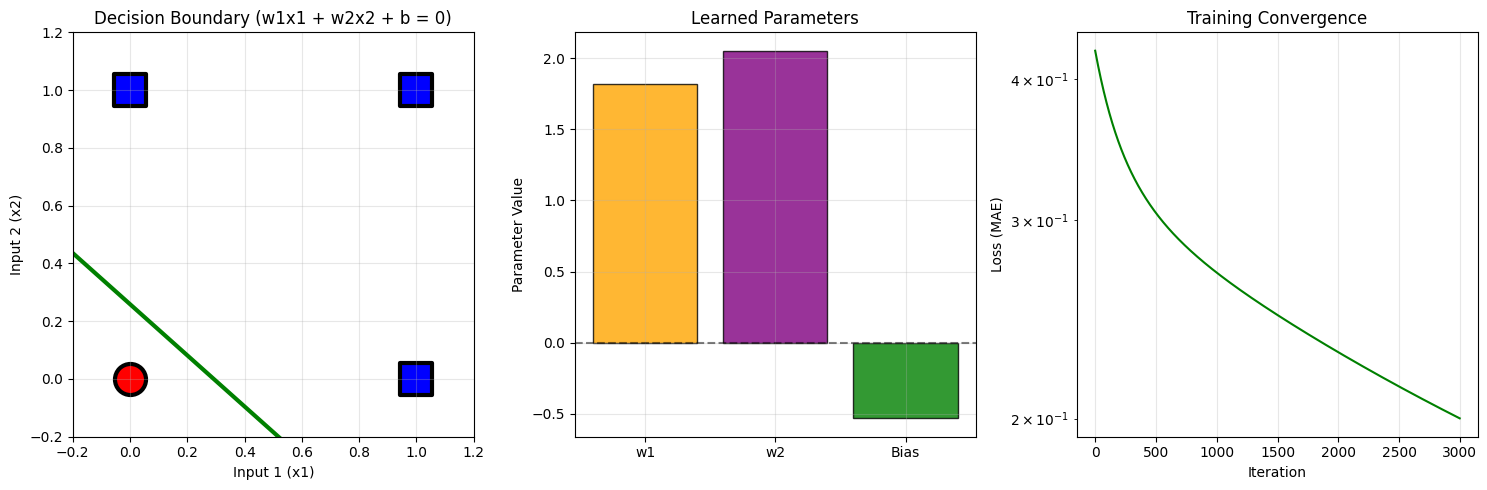


IN DECISION BOUNDARY VERIFICATION:
Equation: 1.818x + 2.053y + -0.531 = 0
Solved for y: y = (-1.818x - -0.531) / 2.053

Point positions relative to boundary:
Input [0 0]: Value -0.531 -> Below (Class 0)
Input [0 1]: Value 1.522 -> Above (Class 1)
Input [1 0]: Value 1.287 -> Above (Class 1)
Input [1 1]: Value 3.339 -> Above (Class 1)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initializing parameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# Training data (OR Gate)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print(f"Initial Bias: {bias[0, 0]:.3f}")

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(x, weights, bias):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

print("\n--- Training single perceptron (OR Gate) ---")
loss_history = []

for iteration in range(iterations):
    # Forward Pass
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    # Error calculation
    error = y - output

    # Backpropagation
    d_output = error * sigmoid_derivative(output)
    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration}: Current Loss: {current_loss:.4f}")

print("\nTraining complete!")
print(f"Final weights: w1 = {weights[0][0]:.3f}, w2 = {weights[1][0]:.3f}")
print(f"Final Bias: {bias[0][0]:.3f}")

# Final Predictions
final_predictions = predict(X, weights, bias)
print("\nIn predictions (OR Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i][0] > 0.5 else 0
    print(f"Input: [{X[i][0]}, {X[i][1]}] Pred: {final_predictions[i][0]:.3f} (Class {pred_class})")

# --- Visualization ---
plt.figure(figsize=(15, 5))

# 1. Decision Boundary
plt.subplot(1, 3, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=500, c='red', marker='o', edgecolors='black', linewidth=3, label='Class 0 (OR=0)')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=500, c='blue', marker='s', edgecolors='black', linewidth=3, label='Class 1 (OR=1)')

# Logic for drawing the line w1*x + w2*y + b = 0
w1, w2 = weights[0, 0], weights[1, 0]
b = bias[0, 0]
boundary_x = np.linspace(-0.2, 1.2, 100)
boundary_y = -(w1 * boundary_x + b) / w2
plt.plot(boundary_x, boundary_y, 'g-', linewidth=3)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('Decision Boundary (w1x1 + w2x2 + b = 0)')
plt.grid(True, alpha=0.3)

# 2. Learned Parameters
plt.subplot(1, 3, 2)
params = ['w1', 'w2', 'Bias']
values = [weights[0,0], weights[1,0], bias[0,0]]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.8, edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# 3. Training Convergence
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, color='g')
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Decision Boundary Verification
print("\nIN DECISION BOUNDARY VERIFICATION:")
print(f"Equation: {weights[0,0]:.3f}x + {weights[1,0]:.3f}y + {bias[0,0]:.3f} = 0")
print(f"Solved for y: y = ({-weights[0,0]:.3f}x - {bias[0,0]:.3f}) / {weights[1,0]:.3f}")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = weights[0,0] * X[i,0] + weights[1,0] * X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value >= 0 else "Below (Class 0)"
    print(f"Input {X[i]}: Value {point_value:.3f} -> {side}")